# Pretrain image segmentation model (unet) for feature generation

This notebook purpose is to pretrain a UNet model on the clean training split, on a classic binary segmentation task, in order to learn useful features for the upcoming model for path classification. The pretrained UNet will be used as a feature extractor for the path classification model, and will be fine-tuned on the path classification task in a second step.

For reproducibility, we provide this notebook to allow people to pretrain themselves the UNet model, but we also provide the pretrained model weights in the repository, so that it is not mandatory to run this notebook (see [README](../README.md)) to be able to train the path classification model.

In [1]:
import torch
import torch.nn as nn
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
import numpy as np
from image_segmentation.data.data_viz import plot_batch

In [2]:
import os
from utils.available_datasets import available_datasets

dataset_choice = available_datasets["FIVES"]

train_split = dataset_choice.preferred_train_split
data_dir = dataset_choice.data_dir
splits_filepath = dataset_choice.splits_filepath

/home/morand/afs/EVAPORE/data/PERSEVERE_subset
3


In [ ]:
train_batch_size = 4
train_patch_size = 1024

## Data visualization
### Show dataset without data augmentation

In [ ]:
from image_segmentation.data.image_datamodule import ImageDatamodule
from image_segmentation.data.image_dataset import ImageDataset

dataset = ImageDataset(data_dir, transforms=None)

train_transforms = A.Compose([
    ToTensorV2(),
], additional_targets={"fg_mask": "mask"})

val_transforms = A.Compose([
    ToTensorV2(),
], additional_targets={"fg_mask": "mask"})

datamodule = ImageDatamodule(
    dataset=dataset,
    split_file_path=splits_filepath,
    train_split_name=train_split,
    val_split_ratio=0.2,
    train_transforms=train_transforms,
    val_transforms=val_transforms,
    test_transforms=val_transforms,
    num_workers=0,
    train_batch_size=train_batch_size,
    val_batch_size=1,
    seed=42,
    shuffle_train=False
)

datamodule.setup()
dataloader = datamodule.train_dataloader()

In [ ]:
for i, batch in enumerate(dataloader):
    plot_batch(batch)
    break

### Show dataset with data augmentation, crop and normalization

In [ ]:
stats = dataset.get_dataset_stats(split_name=train_split)

width, height, n_channels = stats['image_width'], stats['image_height'], stats['n_channels']

mean = stats["foreground"]["mean"]
std = stats["foreground"]["std"]

print(f"Dataset: {dataset}")
print(f"Image Size: {width} x {height}")
print(f"Channels: {n_channels}")
print(f"Mean (only on foreground): {mean}")
print(f"Std (only on foreground): {std}")

In [4]:
from image_segmentation.data.augmentations import build_train_transform, build_val_transform

dataset = ImageDataset(
    data_dir=data_dir,
    transforms=None
)

train_transforms = build_train_transform(mean, std, train_patch_size)
val_transforms = build_val_transform(mean, std)

datamodule = ImageDatamodule(
    dataset=dataset,
    split_file_path=splits_filepath,
    train_split_name=train_split,
    val_split_ratio=0.2,
    train_transforms=train_transforms,
    val_transforms=val_transforms,
    test_transforms=val_transforms,
    num_workers=0,
    train_batch_size=train_batch_size,
    val_batch_size=1,
    seed=42,
    shuffle_train=False
)

datamodule.setup()
dataloader = datamodule.train_dataloader()

Loading dataset stats for split 'train' from /home/morand/afs/EVAPORE/data/PERSEVERE_subset/image_stats.json...
Dataset: <image_segmentation.data.image_dataset.ImageDataset object at 0x7feb09a99eb0>
Mean: [-156.24618685173996]
Std: [385.6239725699534]
Dataset split: Train=20, Val=5, Test=5


/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


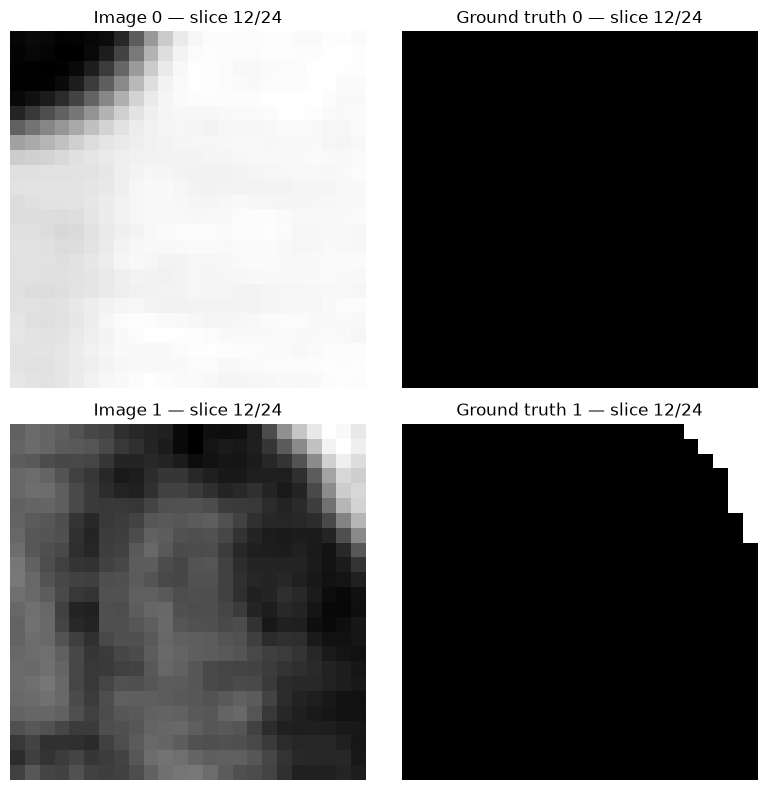

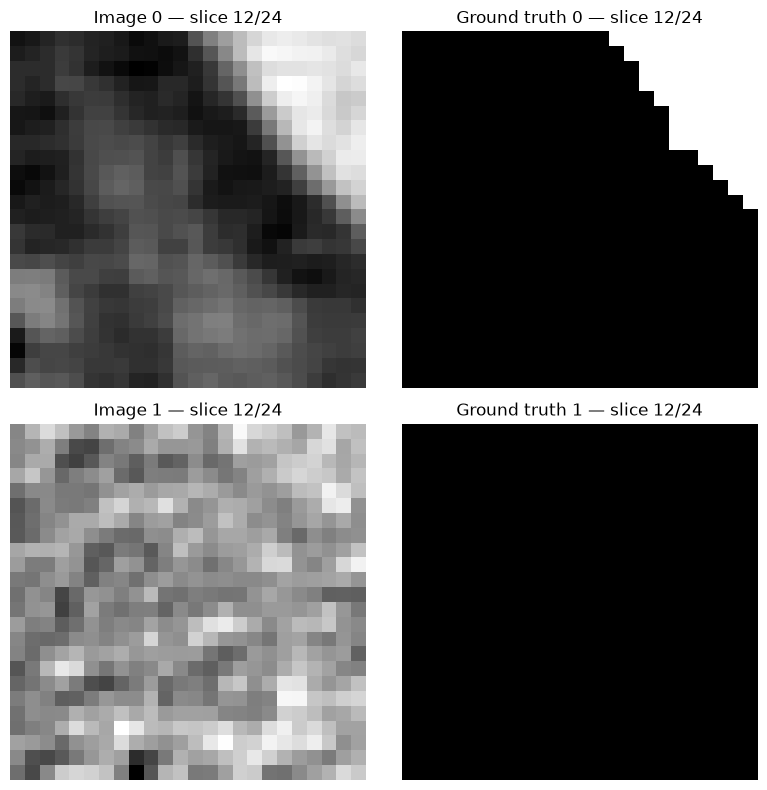

In [6]:
for i, batch in enumerate(dataloader):
    plot_batch(batch)
    break

### Train data augmentation

### Initialize the BinarySegmentator model with the specified hyperparameters, ready for training on the preprocessed dataset.

In [5]:
from image_segmentation.models import BinarySegmentator

binary_segmentator = BinarySegmentator(
    lr=1e-3,
    input_channels=3,
    num_layers=5,
    features_start=32,
    bilinear=True,
    norm_op='instance',
    warmup_epochs=1,
    dropout=0.2,
    kernel_size=3
)

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


### Initialize the callbacks and pytorch-lightning trainer

In [6]:
from pytorch_lightning import Trainer
import torch
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_dir = dataset_choice.get_checkpoint_dir("unet_pretraining")
os.makedirs(checkpoint_dir, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        dirpath=checkpoint_dir,
        monitor="val_loss",
        mode="min",
        save_top_k=1,
        filename="{data_dir}-best-checkpoint-{epoch:02d}-{val_loss:.4f}"
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=100,
        min_delta=0.00,
        verbose=True,
        mode="min"
    )
]

trainer = Trainer(accelerator='cpu', devices="auto", max_epochs=5, precision='16-mixed', callbacks=callbacks)
torch.set_float32_matmul_precision("medium")

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/accelerator_connector.py:479: You passed `Trainer(accelerator='cpu', precision='16-mixed')` but AMP with fp16 is not supported on CPU. Using `precision='bf16-mixed'` instead.
Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try

## Model training

In [9]:
trainer.fit(binary_segmentator, datamodule=datamodule)

Dataset split: Train=20, Val=5, Test=5


/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net           │ UNet              │  1.2 K │ train │     0 │
│ 1 │ bce           │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ dice_loss     │ DiceLoss          │      0 │ train │     0 │
│ 3 │ train_metrics │ ModuleDict        │      0 │ train │     0 │
│ 4 │ val_metrics   │ ModuleDict        │      0 │ train │     0 │
│ 5 │ test_metrics  │ ModuleDict        │      0 │ train │     0 │
└───┴───────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 1.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.2 K                                                                                                
Total estimated model params size (MB): 0.005                                                                      
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:
434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:
434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of 
the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:321: The number of 
training batches (10) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for 
log_every_n_steps if you want to see logs for the training epoch.

Metric val_loss improved. New best score: 0.737
Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.736
Metric val_loss improved by 0.001 >= min_delta = 0.0. New best score: 0.736
Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.735
`Trainer.fit` stopped: `max_epochs=5` reached.


## Testing the model for binary segmentation task

In [7]:
from utils.device import get_device

device = get_device()

ckpt_path = dataset_choice.get_first_checkpoint_path("unet_pretraining")

model = BinarySegmentator.load_from_checkpoint(ckpt_path, map_location=device)


In [8]:
trainer.test(model, datamodule=datamodule)

/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install "ipywidgets" for
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Dataset split: Train=20, Val=5, Test=5


/home/morand/afs/EVAPORE/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.9208478927612305     │
│         test_dice         │     0.15873983502388      │
│         test_loss         │    0.7375129461288452     │
└───────────────────────────┴───────────────────────────┘

[{'test_dice': 0.15873983502388,
  'test_accuracy': 0.9208478927612305,
  'test_loss': 0.7375129461288452}]

torch.Size([1, 1, 410, 311, 422]) torch.Size([1, 1, 410, 311, 422])
Dice Score: 0.20411006


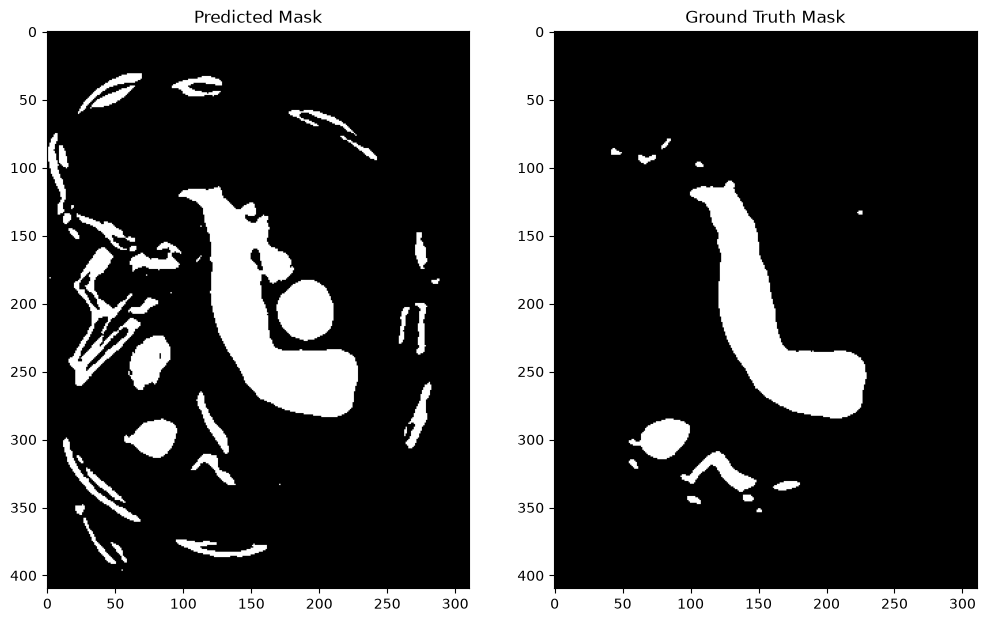

torch.Size([1, 1, 357, 259, 475]) torch.Size([1, 1, 357, 259, 475])
Dice Score: 0.18743469


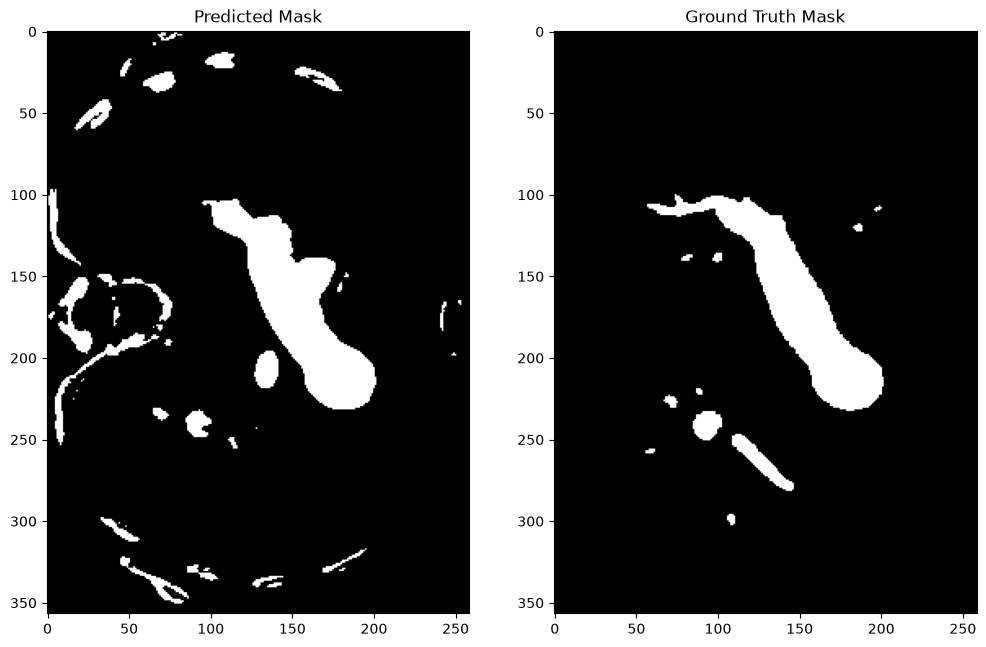

torch.Size([1, 1, 449, 321, 524]) torch.Size([1, 1, 449, 321, 524])
Dice Score: 0.15182626


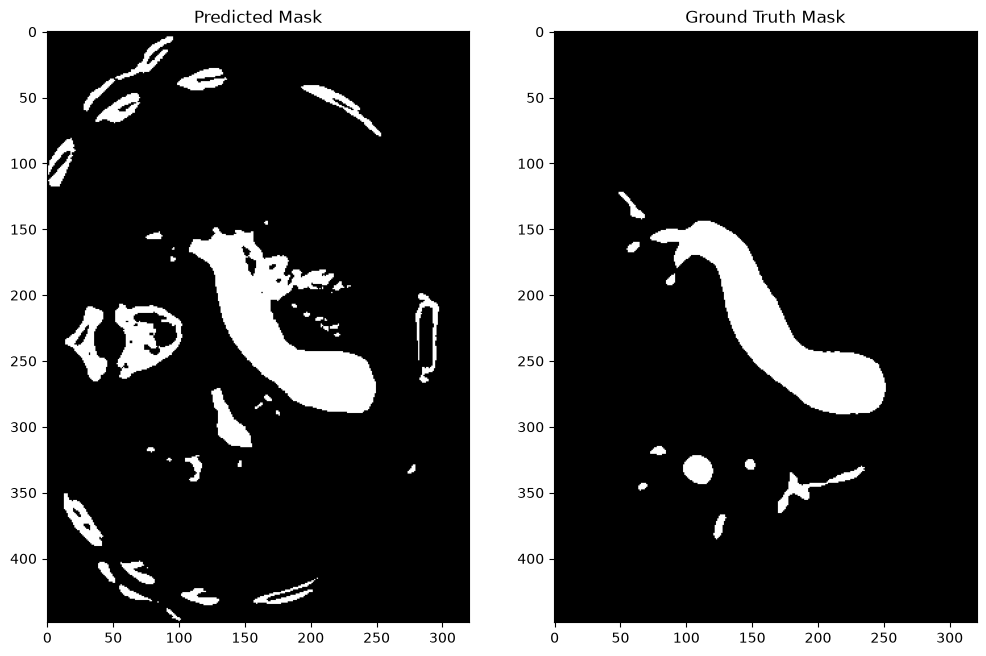

17368

In [13]:
import matplotlib.pyplot as plt
import gc

with torch.no_grad():
    for i, batch in enumerate(datamodule.test_dataloader()):
        imgs, masks = batch

        logits = model(imgs)
        probs = torch.sigmoid(logits)
        binary_preds = (probs > 0.5).float()
        print(probs.shape, binary_preds.shape)

        plt.figure(figsize=(12, 8))
        binary_pred = binary_preds[0, 0].cpu().numpy()
        mask = masks[0, 0].cpu().numpy()

        mid_slice = binary_pred.shape[2] // 2
        plt.subplot(1, 2, 1)
        plt.title("Predicted Mask")
        plt.imshow(binary_pred[:,:,mid_slice], cmap='gray')
        plt.subplot(1, 2, 2)
        plt.title("Ground Truth Mask")
        plt.imshow(mask[:,:,mid_slice], cmap='gray')
        plt.show()
        plt.close('all')
        
        del imgs, masks, logits, probs, binary_preds

        if i >= 2:
            break

torch.cuda.empty_cache()
gc.collect()

Now that we have a trained model for feature extraction, you can continue on the [Segmentation predictions generation notebook (3)](./03_generate_segmentation_preds.ipynb)